# G-PARC Shock Tube — Physics Weight Interpretability

Extracts and visualizes learned weights in `PhysicsFusionMLP` connecting MLS physics features to predicted time derivatives.

**Key targets:**
- `list_fusion[i].net[0].weight` — shape `[128 × 130]` (128 learned + 2 physics cols)
- `list_fusion[i].out.weight` — shape `[1 × 128]`

**Physics column labels (last 2 cols of net[0]):**
- col 128: `∂F/∂x` — MLS flux divergence
- col 129: `∇²φ` — diffusion / Laplacian

**Variables:**
- `fusion[0]` → `dρ/dt`
- `fusion[1]` → `d(ρu)/dt`
- `fusion[2]` → `dE/dt`

## 0. Configuration — edit this cell

In [1]:
CKPT_PATH = '/project/vil_baek/gparc/shock_tube/ST_GPARCV2.pth'
OUT_DIR   = './weight_figs'   # set to None to skip saving PNGs
N_LEARNED = 128
N_PHYS    = 2

## 1. Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

if OUT_DIR:
    os.makedirs(OUT_DIR, exist_ok=True)

VAR_NAMES   = [r'$d\rho/dt$', r'$d(\rho u)/dt$', r'$dE/dt$']
PHYS_LABELS = [r'$\partial F/\partial x$ (MLS flux div.)', r'$\nabla^2\phi$ (diffusion)']

## 2. Load checkpoint

In [3]:
ckpt  = torch.load(CKPT_PATH, map_location='cpu')
state = ckpt['model_state_dict']
print(f'Checkpoint loaded — {len(state)} keys')
print(f'Epoch: {ckpt.get("epoch", "unknown")}   val_loss: {ckpt.get("metrics", {}).get("val_loss", "unknown")}')

Checkpoint loaded — 100 keys
Epoch: 99   val_loss: 3.242681812309911e-07


## 3. Extract fusion weights

In [4]:
fusion_weights = {}

for i in range(3):
    key_net = f'derivative_solver.list_fusion.{i}.net.0.weight'
    key_out = f'derivative_solver.list_fusion.{i}.out.weight'
    key_res = f'derivative_solver.list_fusion.{i}.residual.weight'

    # Fallback: no derivative_solver prefix
    if key_net not in state:
        key_net = f'list_fusion.{i}.net.0.weight'
        key_out = f'list_fusion.{i}.out.weight'
        key_res = f'list_fusion.{i}.residual.weight'

    if key_net in state:
        fusion_weights[i] = {
            'net0': state[key_net].numpy(),
            'out' : state[key_out].numpy(),
            'res' : state[key_res].numpy() if key_res in state else None,
        }
        print(f'fusion[{i}]  net0={fusion_weights[i]["net0"].shape}  out={fusion_weights[i]["out"].shape}')
    else:
        print(f'ERROR: fusion[{i}] not found. Keys containing "fusion":')
        for k in state:
            if 'fusion' in k:
                print(f'  {k}')

assert len(fusion_weights) == 3, 'Could not find all three fusion MLPs — check key names above'

fusion[0]  net0=(128, 130)  out=(1, 128)
fusion[1]  net0=(128, 130)  out=(1, 128)
fusion[2]  net0=(128, 130)  out=(1, 128)


## 4. Figure 1 — Physics weight slice `W[:, 128:]`
Each row is a hidden neuron. The two columns are the MLS physics inputs.

/tmp/ipykernel_168760/1893873824.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


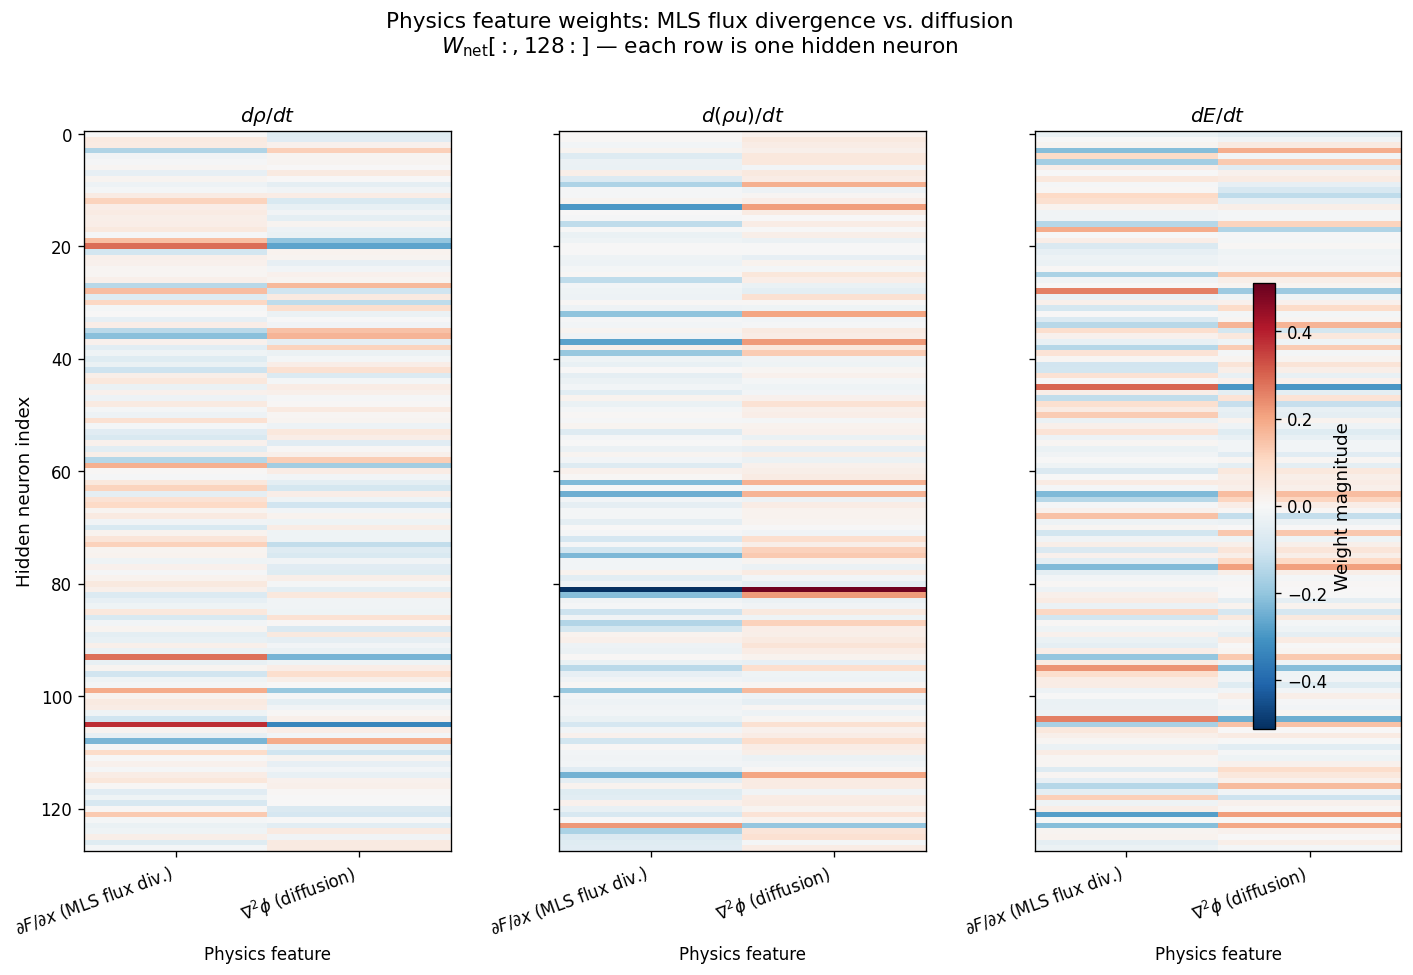

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 8), sharey=True)
fig.suptitle(
    'Physics feature weights: MLS flux divergence vs. diffusion\n'
    r'$W_{\mathrm{net}}[:, 128:]$ — each row is one hidden neuron',
    fontsize=13, y=1.01
)

vmax = max(np.abs(fusion_weights[i]['net0'][:, N_LEARNED:]).max() for i in range(3))

for i, ax in enumerate(axes):
    W_phys = fusion_weights[i]['net0'][:, N_LEARNED:]   # [128, 2]
    im = ax.imshow(W_phys, aspect='auto', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, interpolation='nearest')
    ax.set_title(VAR_NAMES[i], fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(PHYS_LABELS, fontsize=10, rotation=20, ha='right')
    if i == 0:
        ax.set_ylabel('Hidden neuron index', fontsize=11)
    ax.set_xlabel('Physics feature', fontsize=10)

cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Weight magnitude', fontsize=11)
plt.tight_layout()

if OUT_DIR:
    fig.savefig(os.path.join(OUT_DIR, 'fig1_physics_weight_slice.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Figure 2 — Output layer weights
Which hidden neurons drive each `dφ/dt` prediction.

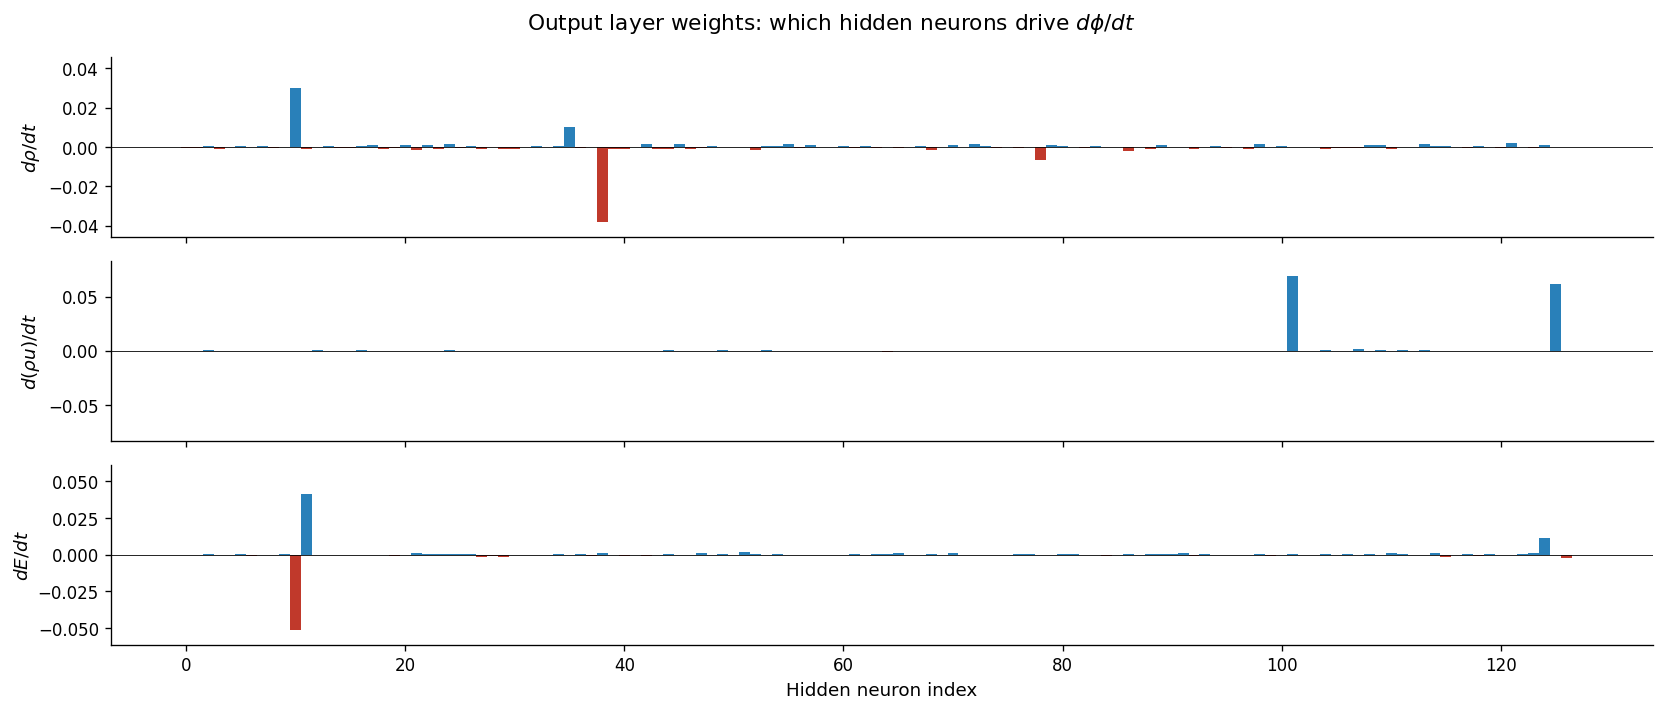

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
fig.suptitle(r'Output layer weights: which hidden neurons drive $d\phi/dt$', fontsize=13)

for i, ax in enumerate(axes):
    w = fusion_weights[i]['out'][0]   # [128]
    colors = ['#c0392b' if v < 0 else '#2980b9' for v in w]
    ax.bar(np.arange(len(w)), w, color=colors, width=1.0, linewidth=0)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel(VAR_NAMES[i], fontsize=11)
    ax.set_ylim(-np.abs(w).max() * 1.2, np.abs(w).max() * 1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Hidden neuron index', fontsize=11)
plt.tight_layout()

if OUT_DIR:
    fig.savefig(os.path.join(OUT_DIR, 'fig2_output_weights.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Figure 3 — Physics trust ratio
Frobenius norm of physics columns vs. learned columns, per variable.
- **Ratio > 1**: network trusts MLS physics more than GNN features
- **Ratio < 1**: network relies more on learned GNN representation

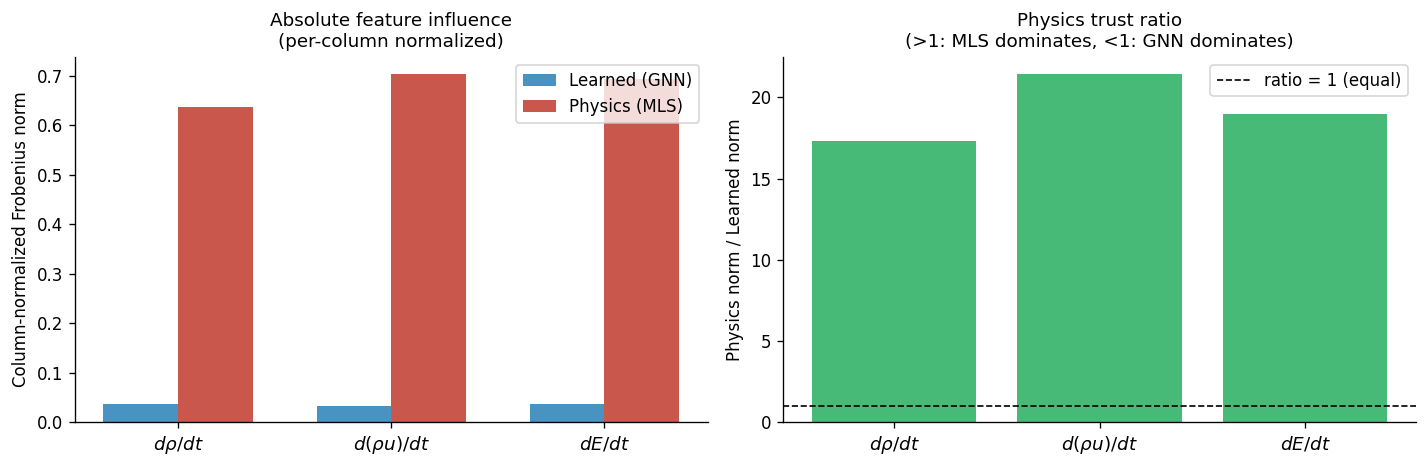


Physics trust ratios:
  $d\rho/dt$            physics=0.6372  learned=0.0368  ratio=17.299
  $d(\rho u)/dt$        physics=0.7036  learned=0.0328  ratio=21.429
  $dE/dt$               physics=0.6947  learned=0.0366  ratio=18.974


In [7]:
learned_norms, physics_norms, ratios = [], [], []

for i in range(3):
    W = fusion_weights[i]['net0']
    ln = np.linalg.norm(W[:, :N_LEARNED], 'fro') / N_LEARNED
    pn = np.linalg.norm(W[:, N_LEARNED:], 'fro') / N_PHYS
    learned_norms.append(ln)
    physics_norms.append(pn)
    ratios.append(pn / (ln + 1e-8))

x, width = np.arange(3), 0.35
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(x - width/2, learned_norms, width, label='Learned (GNN)', color='#2980b9', alpha=0.85)
ax.bar(x + width/2, physics_norms, width, label='Physics (MLS)', color='#c0392b', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(VAR_NAMES, fontsize=11)
ax.set_ylabel('Column-normalized Frobenius norm', fontsize=10)
ax.set_title('Absolute feature influence\n(per-column normalized)', fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
bar_colors = ['#27ae60' if r >= 1 else '#e67e22' for r in ratios]
ax.bar(x, ratios, color=bar_colors, alpha=0.85)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='ratio = 1 (equal)')
ax.set_xticks(x)
ax.set_xticklabels(VAR_NAMES, fontsize=11)
ax.set_ylabel('Physics norm / Learned norm', fontsize=10)
ax.set_title('Physics trust ratio\n(>1: MLS dominates, <1: GNN dominates)', fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

if OUT_DIR:
    fig.savefig(os.path.join(OUT_DIR, 'fig3_physics_trust_ratio.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nPhysics trust ratios:')
for i in range(3):
    print(f'  {VAR_NAMES[i]:20s}  physics={physics_norms[i]:.4f}  learned={learned_norms[i]:.4f}  ratio={ratios[i]:.3f}')

## 7. Figure 4 — Per-neuron physics vs. learned dominance
Each dot is one hidden neuron. Neurons above the diagonal are physics-dominant.

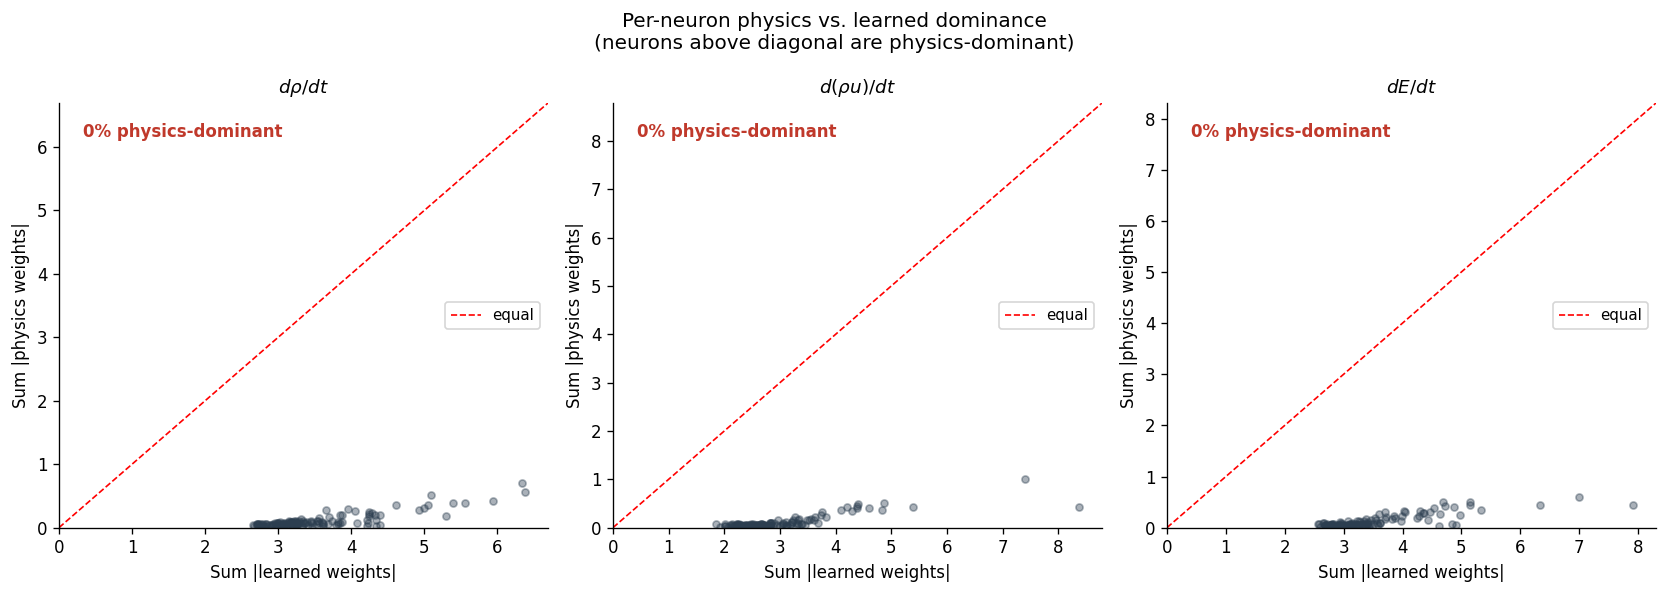

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    'Per-neuron physics vs. learned dominance\n'
    '(neurons above diagonal are physics-dominant)',
    fontsize=12
)

for i, ax in enumerate(axes):
    W = fusion_weights[i]['net0']
    learned_sum = np.abs(W[:, :N_LEARNED]).sum(axis=1)
    physics_sum = np.abs(W[:, N_LEARNED:]).sum(axis=1)

    ax.scatter(learned_sum, physics_sum, alpha=0.4, s=18, color='#2c3e50')
    lim = max(learned_sum.max(), physics_sum.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='equal')
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel('Sum |learned weights|', fontsize=10)
    ax.set_ylabel('Sum |physics weights|', fontsize=10)
    ax.set_title(VAR_NAMES[i], fontsize=11)
    ax.legend(fontsize=9)

    frac = (physics_sum > learned_sum).mean()
    ax.text(0.05, 0.92, f'{frac*100:.0f}% physics-dominant',
            transform=ax.transAxes, fontsize=10, color='#c0392b', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

if OUT_DIR:
    fig.savefig(os.path.join(OUT_DIR, 'fig4_per_neuron_dominance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary — top-5 output neurons per variable

In [9]:
print('=' * 60)
print('WEIGHT SUMMARY')
print('=' * 60)

for i in range(3):
    W      = fusion_weights[i]['net0']
    W_phys = W[:, N_LEARNED:]
    W_out  = fusion_weights[i]['out'][0]

    flux_col = W_phys[:, 0]
    diff_col = W_phys[:, 1]

    print(f'\nVariable: {VAR_NAMES[i]}')
    print(f'  net[0] shape:         {W.shape}')
    print(f'  flux div col norm:    {np.linalg.norm(flux_col):.4f}')
    print(f'  diffusion col norm:   {np.linalg.norm(diff_col):.4f}')
    print(f'  output weight norm:   {np.linalg.norm(W_out):.4f}')
    print(f'  flux/diffusion ratio: {np.linalg.norm(flux_col) / (np.linalg.norm(diff_col) + 1e-8):.3f}')

    top5 = np.argsort(np.abs(W_out))[::-1][:5]
    print(f'  top-5 output neurons: {top5.tolist()}')
    print(f'  their physics weights (flux, diff):')
    for n in top5:
        print(f'    neuron {n:3d}: flux={W_phys[n,0]:+.4f}  diff={W_phys[n,1]:+.4f}  out={W_out[n]:+.4f}')

print('\n' + '=' * 60)

WEIGHT SUMMARY

Variable: $d\rho/dt$
  net[0] shape:         (128, 130)
  flux div col norm:    0.9369
  diffusion col norm:   0.8639
  output weight norm:   0.0508
  flux/diffusion ratio: 1.085
  top-5 output neurons: [38, 10, 35, 78, 86]
  their physics weights (flux, diff):
    neuron  38: flux=-0.0539  diff=+0.1123  out=-0.0382
    neuron  10: flux=-0.0112  diff=-0.0186  out=+0.0302
    neuron  35: flux=-0.1394  diff=+0.1486  out=+0.0100
    neuron  78: flux=-0.0066  diff=-0.0636  out=-0.0065
    neuron  86: flux=-0.0794  diff=+0.0748  out=-0.0022

Variable: $d(\rho u)/dt$
  net[0] shape:         (128, 130)
  flux div col norm:    1.0640
  diffusion col norm:   0.9209
  output weight norm:   0.0927
  flux/diffusion ratio: 1.155
  top-5 output neurons: [101, 125, 107, 64, 44]
  their physics weights (flux, diff):
    neuron 101: flux=-0.0247  diff=-0.0455  out=+0.0692
    neuron 125: flux=-0.0742  diff=+0.0791  out=+0.0616
    neuron 107: flux=+0.0207  diff=+0.0368  out=+0.0014
    

In [10]:
# Two-hop pathway analysis — net[2] weights
# net[2] is the second Linear layer: [128 x 128]
two_hop = {}

for i in range(3):
    key = f'derivative_solver.list_fusion.{i}.net.2.weight'
    if key not in state:
        key = f'list_fusion.{i}.net.2.weight'
    if key in state:
        two_hop[i] = state[key].numpy()   # [128, 128]
        print(f'fusion[{i}] net[2]: {two_hop[i].shape}')
    else:
        print(f'ERROR: net[2] not found for fusion[{i}]')
        for k in state:
            if 'fusion' in k and 'net' in k:
                print(f'  {k}')

fusion[0] net[2]: (128, 128)
fusion[1] net[2]: (128, 128)
fusion[2] net[2]: (128, 128)


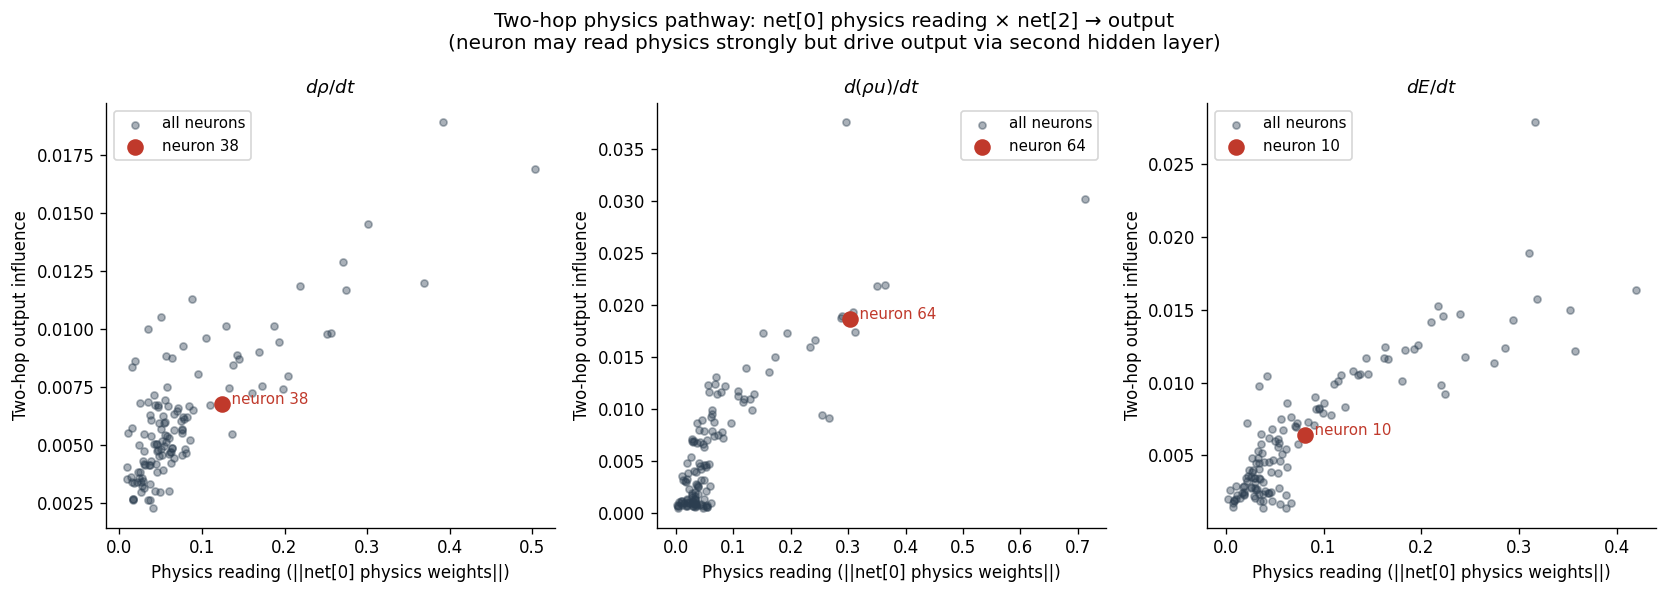

In [11]:
# For each variable, score each hidden neuron by:
#   physics_reading  = |net0 physics weight| (how strongly it reads MLS)
#   output_influence = |net2 col| dot |out weight| (how much it drives output via layer 2)
# Neuron 64 for d(rho*u)/dt is the specific case to highlight

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Two-hop physics pathway: net[0] physics reading × net[2] → output\n'
             '(neuron may read physics strongly but drive output via second hidden layer)',
             fontsize=12)

highlight_neurons = {0: 38, 1: 64, 2: 10}  # top physics reader per variable

for i, ax in enumerate(axes):
    W0_phys = fusion_weights[i]['net0'][:, N_LEARNED:]   # [128, 2]
    W2      = two_hop[i]                                  # [128, 128]
    W_out   = fusion_weights[i]['out'][0]                 # [128]

    # Physics reading score per neuron: L2 norm of its physics weights in net[0]
    phys_read = np.linalg.norm(W0_phys, axis=1)          # [128]

    # Two-hop output influence: how much does neuron j in layer 1
    # drive the output via layer 2?
    # W2[k, j] = weight from hidden1[j] to hidden2[k]
    # W_out[k]  = weight from hidden2[k] to output
    # two_hop_influence[j] = sum_k |W2[k,j]| * |W_out[k]|
    two_hop_inf = (np.abs(W2) * np.abs(W_out)[:, None]).sum(axis=0)  # [128]

    # Direct output influence (from net[0] neurons directly via out layer)
    direct_inf = np.abs(W_out)   # [128]

    ax.scatter(phys_read, two_hop_inf, alpha=0.4, s=18, color='#2c3e50', label='all neurons')

    # Highlight specific neuron
    n = highlight_neurons[i]
    ax.scatter(phys_read[n], two_hop_inf[n], s=80, color='#c0392b', zorder=5,
               label=f'neuron {n}')
    ax.annotate(f'  neuron {n}', (phys_read[n], two_hop_inf[n]),
                fontsize=9, color='#c0392b')

    ax.set_xlabel('Physics reading (||net[0] physics weights||)', fontsize=10)
    ax.set_ylabel('Two-hop output influence', fontsize=10)
    ax.set_title(VAR_NAMES[i], fontsize=11)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
if OUT_DIR:
    fig.savefig(os.path.join(OUT_DIR, 'fig5_two_hop_pathway.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
for i in range(3):
    W0_phys = fusion_weights[i]['net0'][:, N_LEARNED:]
    W2      = two_hop[i]
    W_out   = fusion_weights[i]['out'][0]

    phys_read   = np.linalg.norm(W0_phys, axis=1)
    two_hop_inf = (np.abs(W2) * np.abs(W_out)[:, None]).sum(axis=0)

    # Combined score: physics reading × two-hop influence
    combined = phys_read * two_hop_inf
    top3 = np.argsort(combined)[::-1][:3]

    print(f'\n{VAR_NAMES[i]} — top-3 by combined physics×influence score:')
    for n in top3:
        print(f'  neuron {n:3d}:  phys_read={phys_read[n]:.4f}  '
              f'two_hop_inf={two_hop_inf[n]:.4f}  '
              f'flux={W0_phys[n,0]:+.4f}  diff={W0_phys[n,1]:+.4f}')


$d\rho/dt$ — top-3 by combined physics×influence score:
  neuron 105:  phys_read=0.5031  two_hop_inf=0.0169  flux=+0.3773  diff=-0.3328
  neuron  20:  phys_read=0.3924  two_hop_inf=0.0189  flux=+0.2850  diff=-0.2697
  neuron  93:  phys_read=0.3693  two_hop_inf=0.0120  flux=+0.2817  diff=-0.2389

$d(\rho u)/dt$ — top-3 by combined physics×influence score:
  neuron  81:  phys_read=0.7129  two_hop_inf=0.0302  flux=-0.5116  diff=+0.4965
  neuron 123:  phys_read=0.2965  two_hop_inf=0.0375  flux=+0.2215  diff=-0.1972
  neuron  13:  phys_read=0.3649  two_hop_inf=0.0219  flux=-0.2955  diff=+0.2141

$dE/dt$ — top-3 by combined physics×influence score:
  neuron  28:  phys_read=0.3165  two_hop_inf=0.0279  flux=+0.2571  diff=-0.1845
  neuron  45:  phys_read=0.4194  two_hop_inf=0.0164  flux=+0.2963  diff=-0.2967
  neuron  77:  phys_read=0.3098  two_hop_inf=0.0189  flux=-0.2274  diff=+0.2104


In [13]:
print('Flux/diffusion contrast analysis:')
print(f'{"Var":<15} {"Neuron":>6} {"flux":>8} {"diff":>8} {"ratio flux/diff":>16} {"sign pattern":>14}')
print('-' * 70)

var_keys = {0: VAR_NAMES[0], 1: VAR_NAMES[1], 2: VAR_NAMES[2]}
top_neurons = {
    0: [105, 20, 93],
    1: [81, 123, 13],
    2: [28, 45, 77],
}

for i, neurons in top_neurons.items():
    W0_phys = fusion_weights[i]['net0'][:, N_LEARNED:]
    for n in neurons:
        f = W0_phys[n, 0]
        d = W0_phys[n, 1]
        ratio = f / (d + 1e-8) if abs(d) > 1e-6 else float('inf')
        sign = '+flux/-diff' if f > 0 and d < 0 else '-flux/+diff' if f < 0 and d > 0 else 'same sign'
        print(f'{VAR_NAMES[i]:<15} {n:>6} {f:>+8.4f} {d:>+8.4f} {ratio:>16.3f} {sign:>14}')
    print()

Flux/diffusion contrast analysis:
Var             Neuron     flux     diff  ratio flux/diff   sign pattern
----------------------------------------------------------------------
$d\rho/dt$         105  +0.3773  -0.3328           -1.134    +flux/-diff
$d\rho/dt$          20  +0.2850  -0.2697           -1.057    +flux/-diff
$d\rho/dt$          93  +0.2817  -0.2389           -1.179    +flux/-diff

$d(\rho u)/dt$      81  -0.5116  +0.4965           -1.030    -flux/+diff
$d(\rho u)/dt$     123  +0.2215  -0.1972           -1.123    +flux/-diff
$d(\rho u)/dt$      13  -0.2955  +0.2141           -1.380    -flux/+diff

$dE/dt$             28  +0.2571  -0.1845           -1.393    +flux/-diff
$dE/dt$             45  +0.2963  -0.2967           -0.999    +flux/-diff
$dE/dt$             77  -0.2274  +0.2104           -1.080    -flux/+diff



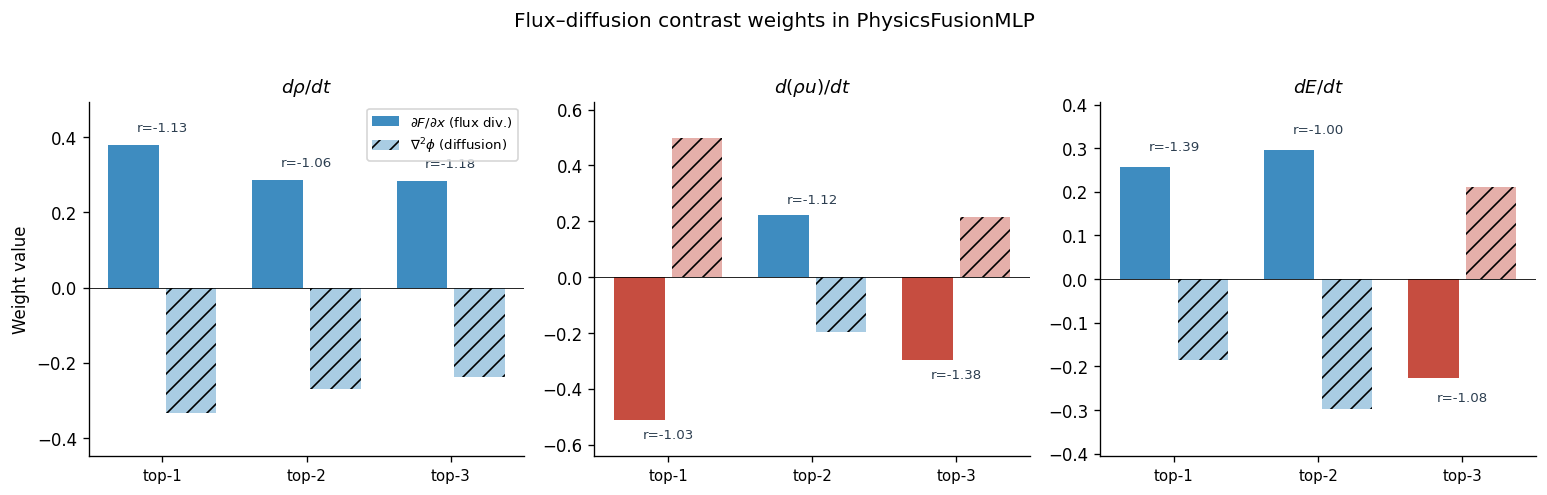

In [15]:
# Fig 6 — Flux/diffusion contrast: the dominant learned physics operation
top_neurons = {0: [105, 20, 93], 1: [81, 123, 13], 2: [28, 45, 77]}
colors_pos = '#2980b9'
colors_neg = '#c0392b'

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(
    'Flux\u2013diffusion contrast weights in PhysicsFusionMLP',
    fontsize=12, y=1.02
)

for i, ax in enumerate(axes):
    W0_phys = fusion_weights[i]['net0'][:, N_LEARNED:]
    neurons = top_neurons[i]

    x = np.arange(len(neurons))
    flux_vals = [W0_phys[n, 0] for n in neurons]
    diff_vals = [W0_phys[n, 1] for n in neurons]
    ratios    = [f / (d + 1e-8) for f, d in zip(flux_vals, diff_vals)]

    bar_colors = [colors_pos if f > 0 else colors_neg for f in flux_vals]
    diff_colors = [colors_pos if f > 0 else colors_neg for f in flux_vals]

    ax.bar(x - 0.2, flux_vals, 0.35,
           label=r'$\partial F/\partial x$ (flux div.)',
           color=bar_colors, alpha=0.9)
    ax.bar(x + 0.2, diff_vals, 0.35,
           label=r'$\nabla^2\phi$ (diffusion)',
           color=diff_colors, alpha=0.4, hatch='//')

    ax.axhline(0, color='black', linewidth=0.5)

    # Ratio annotations — clamp to stay inside axes
    for j, (f, d, r) in enumerate(zip(flux_vals, diff_vals, ratios)):
        yoffset = 0.03
        if f > 0:
            ypos = max(f, abs(d)) + yoffset
            va = 'bottom'
        else:
            ypos = min(f, -abs(d)) - yoffset
            va = 'top'
        ax.text(j, ypos, f'r={r:.2f}', ha='center', va=va,
                fontsize=8, color='#2c3e50')

    ax.set_xticks(x)
    ax.set_xticklabels([f'top-{k+1}' for k in range(len(neurons))], fontsize=9)
    ax.set_title(VAR_NAMES[i], fontsize=11)
    if i == 0:
        ax.set_ylabel('Weight value', fontsize=10)
        ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Pad y-axis so annotations don't clip
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - 0.08, ymax + 0.08)

plt.tight_layout()
if OUT_DIR:
    fig.savefig(os.path.join(OUT_DIR, 'fig6_flux_diffusion_contrast.png'),
                dpi=150, bbox_inches='tight')
plt.show()